# **Влияние социальных сетей на учащихся**
В данной работе будет проводиться анализ влияния социальных сетей на успеваемость учащихся, основываясь на различных аспектах их жизни, включая академическую успеваемость, психическое здоровье, сон и отношения.

# **Используемые данные**
Данные были взяты из базы наборов данных **Kaggel**.\
Набор данных **Student Social Media & Relationships** содержит анонимные записи поведения учащихся в социальных сетях и связанных с этим жизненных результатов. Он охватывает несколько стран и академических уровней, фокусируясь на ключевых измерениях, таких как интенсивность использования, предпочтения платформы и динамика отношений. Каждая строка представляет собой ответ одного учащегося на опрос, предоставляя перекрестный срез данных, подходящий для статистического анализа и приложений машинного обучения.

# **Область действия и охват данных**
*   *Население:* учащиеся в возрасте 16–25 лет, обучающиеся по программам средней школы, бакалавриата или магистратуры.
*   *География:* покрытие нескольких стран (например, Бангладеш, Индия, США, Великобритания, Канада, Австралия, Германия, Бразилия, Япония, Южная Корея).
*   *Временные рамки:* данные собраны в ходе одноразового онлайн-опроса, проведенного в первом квартале 2025 года.

# **Переменные**
1. **Student_ID** (Integer) - уникальный идентификатор респондента;
2. **Age** (Integer) - возраст в годах;
3. **Gender** (Categorical) - пол респондента: мужчина (Male) или женщина (Female);
4. **Academic_Level** (Categorical) - академический уровень (High School / Undergraduate / Graduate);
5. **Country** (Categorical) - страна проживания респондента;
6. **Avg_Daily_Usage_Hours** (Float) - среднее количество часов в день в социальных сетях;
7. **Most_Used_Platform** (Categorical) - наиболее используемая платформа (Instagram, Facebook, TikTok, и т.д.);
8. **Affects_Academic_Performance** (Boolean) - оценка влияния на успеваемость (Yes / No);
9. **Sleep_Hours_Per_Night** (Float) - средняя продолжительность ночного сна;
10. **Mental_Health_Score** (Integer) - оценка психического здоровья (от 1 = плохое до 10 = отличное);
11. **Relationship_Status** (Categorical) - статус отношений (Single / In Relationship / Complicated);
12. **Conflicts_Over_Social_Media** (Integer) - количество конфликтов в отношениях из-за социальных сетей;
13. **Addicted_Score** (Integer) - оценка зависимости от социальных сетей (от 1 = низкая до 10 = высокая).










In [ ]:
# Используемые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Загрузка данных
data = pd.read_csv('Students Social Media Addiction.csv')
data

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


# **Предварительная обработка**


Количество пропущенных значений в каждом столбце:
Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64


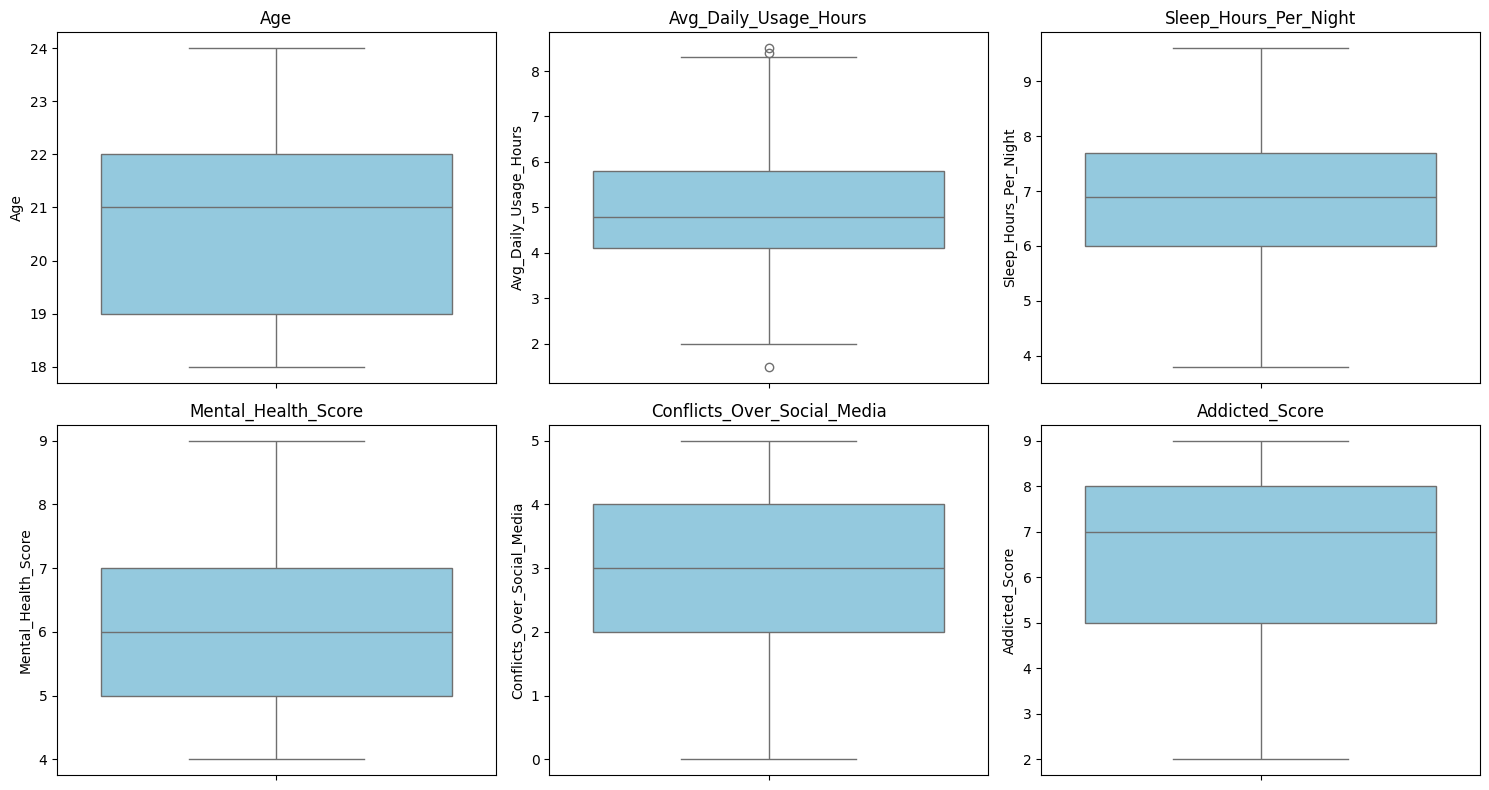

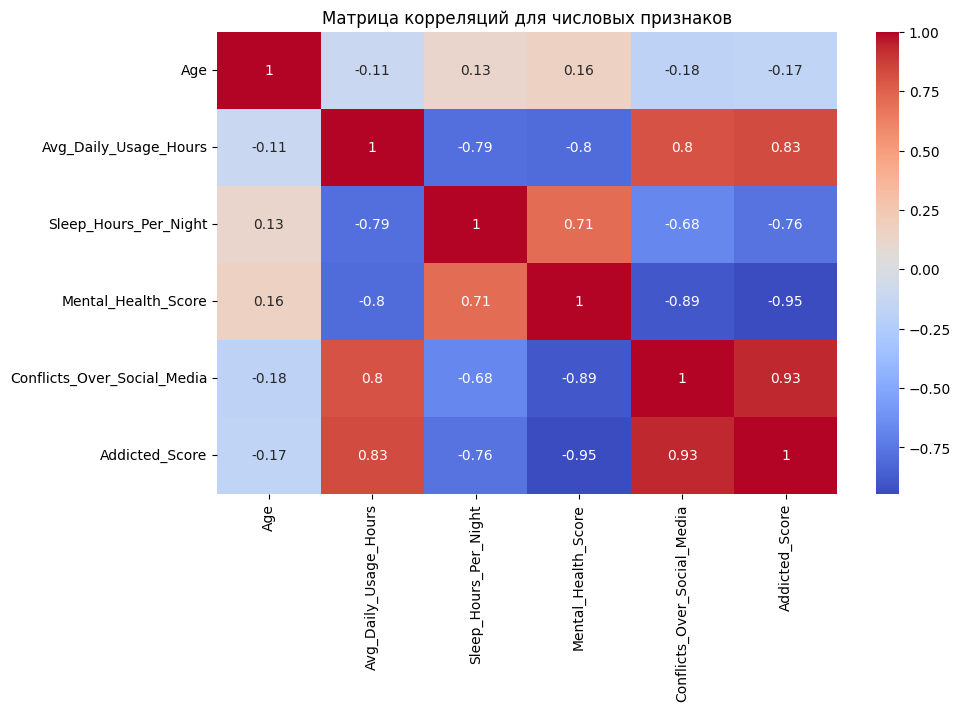

In [ ]:
numerical_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score']
categorical_cols = ["Gender", "Academic_Level", "Country", "Most_Used_Platform", "Relationship_Status"]

# Проверка на пропущенные значения
print("Количество пропущенных значений в каждом столбце:\n", data.isnull().sum(), sep='')

# Заполнение пропусков
for col in data.columns:
    if data[col].dtype == 'object':  # Категориальные признаки
        data[col].fillna(data[col].mode()[0], inplace=True)
    else:  # Числовые признаки
        data[col].fillna(data[col].mean(), inplace=True)

# Подготовка данных
X = data.drop(columns=["Affects_Academic_Performance", "Student_ID"])
y = data["Affects_Academic_Performance"]

# Проверка на выбросы
plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols, 1): # Боксплоты для числовых признаков
    plt.subplot(2, 3, i)
    sns.boxplot(y=X[col], color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

# Замена выбросов граничными значениями
for col in numerical_cols:
    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5*iqr
    upper_bound = q3 + 1.5*iqr

    X[col] = np.where(X[col] < lower_bound, lower_bound, X[col])
    X[col] = np.where(X[col] > upper_bound, upper_bound, X[col])

# Матрица корреляций числовых признаков
plt.figure(figsize=(10, 6))
sns.heatmap(data[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Матрица корреляций для числовых признаков")
plt.show()

# Кодирование категориальных переменных
X = pd.get_dummies(X, columns=categorical_cols)

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Масштабирование числовых признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

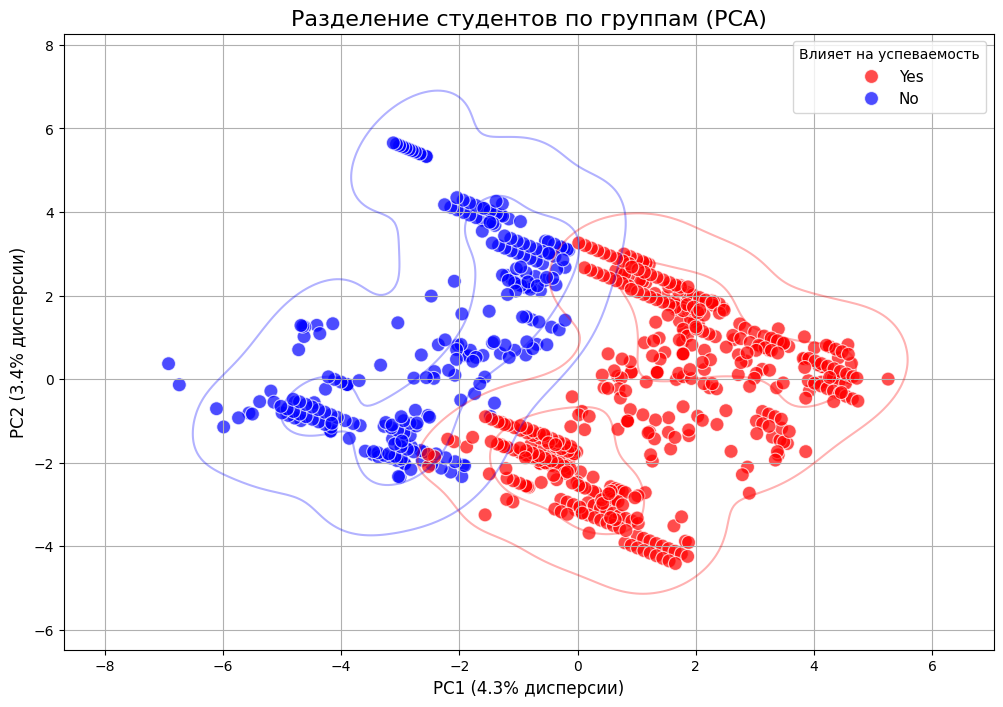

In [ ]:
# Масштабирование данных (важно для PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Применение PCA для уменьшения до 2 компонент
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Создание DataFrame для визуализации
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Affects_Academic_Performance'] = y.reset_index(drop=True)

# Визуализация
plt.figure(figsize=(12, 8))
sns.scatterplot(data=pca_df,
                x='PC1',
                y='PC2',
                hue='Affects_Academic_Performance',
                palette={'Yes': 'red', 'No': 'blue'},
                alpha=0.7,
                s=100)

plt.title('Разделение студентов по группам (PCA)', fontsize=16)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% дисперсии)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% дисперсии)', fontsize=12)
plt.legend(title='Влияет на успеваемость', fontsize=11)
plt.grid(True)

# Добавляем эллипсы для визуализации плотности
sns.kdeplot(data=pca_df[pca_df['Affects_Academic_Performance'] == 'Yes'],
            x='PC1', y='PC2',
            levels=3, color='red', alpha=0.3)
sns.kdeplot(data=pca_df[pca_df['Affects_Academic_Performance'] == 'No'],
            x='PC1', y='PC2',
            levels=3, color='blue', alpha=0.3)

plt.show()

**Наблюдения, сделанные в результате обработки данных**

Данные, который мы используем в данном исследовании, не содержат пропусков и выбросов. Числовые признаки хорошо коррелируют, что позволит получить нам высокую точность при моделировании. Также данные образуют группы, то есть они более менее разделены друг от друга, хотя и есть небольшое пересечение (PCA). В общем и целом, данные неплохие.

# **Постановка задачи**
Построить несколько моделей, решающих задачу бинарной классификации (на основе предикторой и получаем отклик Affects_Academic_Performance), и сравнить качество их оценки для данного датасета.

Применим следующие модели:
*   Дерево решений (Decision Tree)
*   Метод k-ближайших соседей (KNN)
*   Логистическая регрессия (Logistic Regression)

Именно эти модели лучше всего подходят для задачи бинарной классификации.
Также важно отметить, что у них есть отличия, которые и буду влиять на классификацию:

*   Данные: Decision Tree может работать с категориальными признаками без предварительного кодирования, в то время как Logistic Regression и KNN - нет;
*   Разные подходы к анализу: Logistic Regression - линейная зависимость между признаками и целевой переменной, Decision Tree - нелинейные взаимодействия, а KNN - локальные закономерности;

То есть все три модели дадут возможность по-разному посмотреть на данные и определить, какой из методов лучше.


# **Дерево решений (Decision Tree)**

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

          No       1.00      1.00      1.00        77
         Yes       1.00      1.00      1.00       135

    accuracy                           1.00       212
   macro avg       1.00      1.00      1.00       212
weighted avg       1.00      1.00      1.00       212



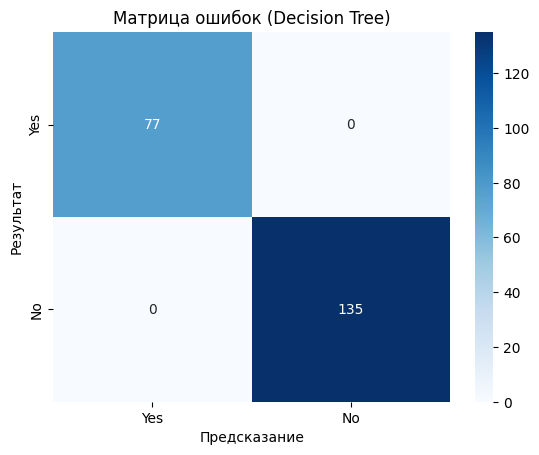

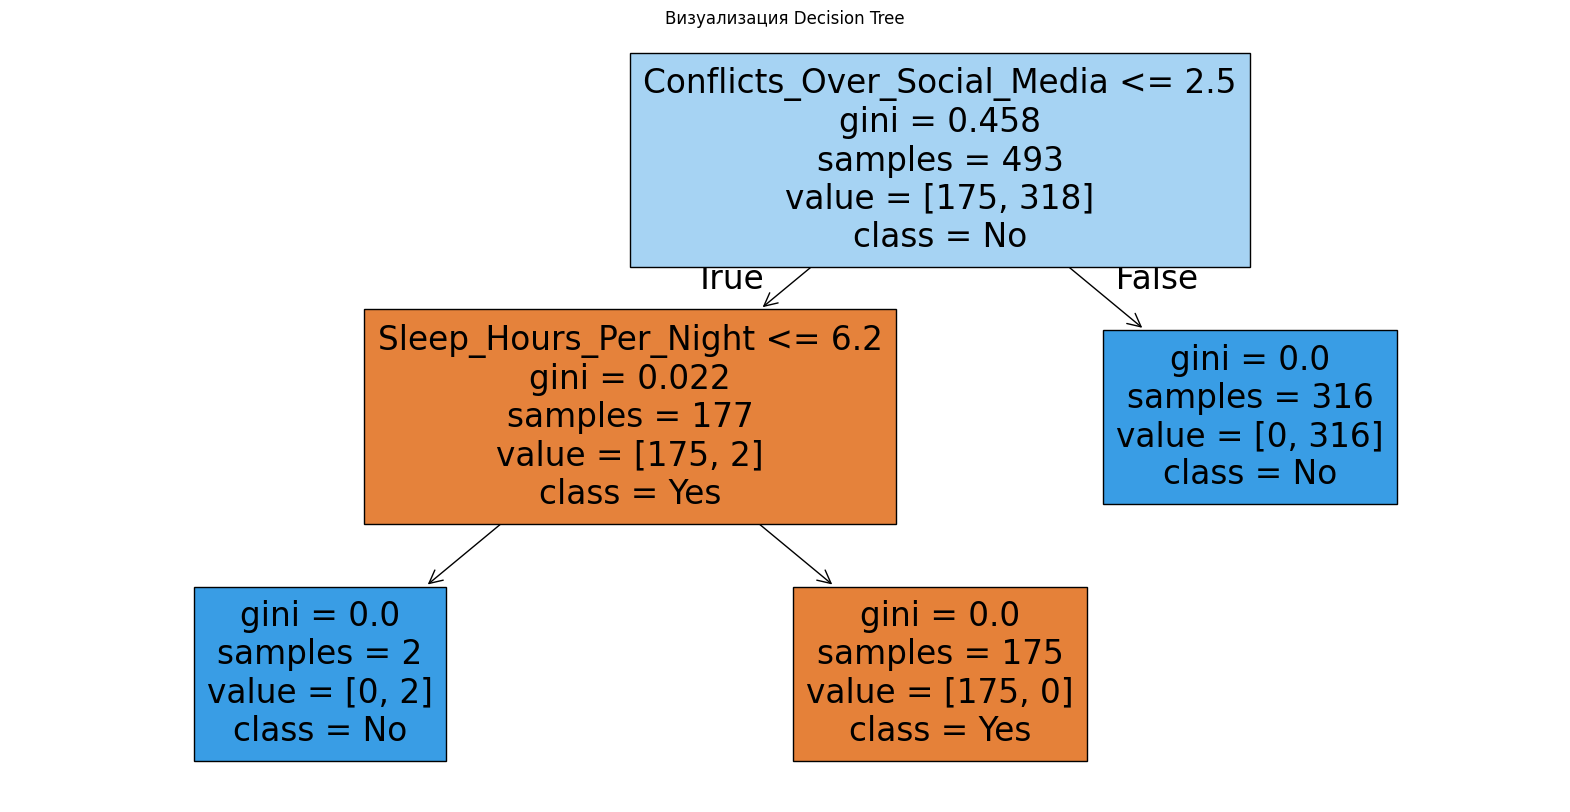

In [ ]:
# Обучение модели Decision Tree
dt_model = DecisionTreeClassifier(random_state=37, criterion='gini')
dt_model.fit(X_train, y_train)  # Дерево не требует масштабирования

# Предсказание и оценка
y_pred = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=y.unique(), yticklabels=y.unique())
plt.title("Матрица ошибок (Decision Tree)")
plt.xlabel("Предсказание")
plt.ylabel("Результат")
plt.show()

# Визуализация дерева
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=y.unique(), filled=True)
plt.title("Визуализация Decision Tree")
plt.show()

**Наблюдения:**

Метод показал очень интересный результат: с одной стороны можно сказать, что он идеально справляется со своей задачей, но с другой - это признак того, что либо модель переобучилась, либо данные слишком простые (что вероятнее в нашем случае), либо есть утечки данных.

Также хочется отметить, что глубина дерева совсем небольшая, что говорит нам о том, что очень сильно на успеваемость влияют количество конфликтов в отношениях из-за социальных сетей и средняя продолжительность ночного сна.

# **Метод k-ближайших соседей (KNN)**

KNN Accuracy: 0.9669811320754716
              precision    recall  f1-score   support

          No       0.97      0.94      0.95        77
         Yes       0.96      0.99      0.97       135

    accuracy                           0.97       212
   macro avg       0.97      0.96      0.96       212
weighted avg       0.97      0.97      0.97       212



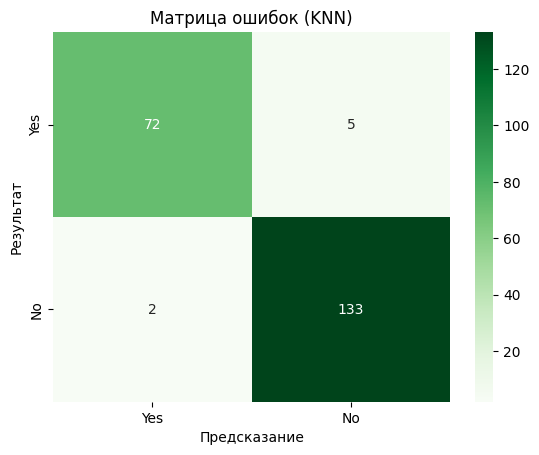

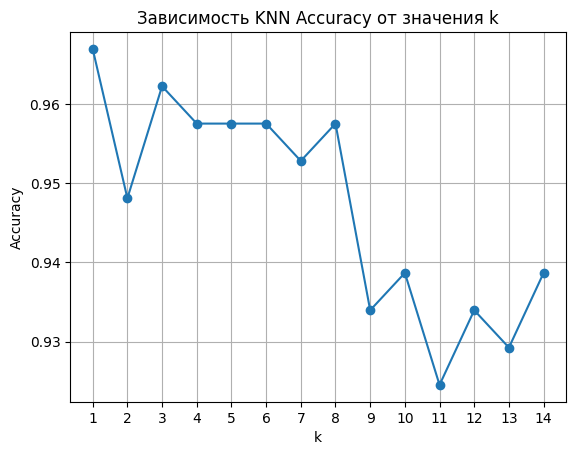

In [ ]:
# Обучение модели KNN (используем масштабированные данные)
knn_model = KNeighborsClassifier(n_neighbors=1)
knn_model.fit(X_train_scaled, y_train)

# Предсказание и оценка
y_pred = knn_model.predict(X_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=y.unique(), yticklabels=y.unique())
plt.title("Матрица ошибок (KNN)")
plt.xlabel("Предсказание")
plt.ylabel("Результат")
plt.show()

# График точности для разных k
k_values = range(1, 15)
accuracy_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracy_scores.append(knn.score(X_test_scaled, y_test))

plt.plot(k_values, accuracy_scores, marker='o')
plt.title("Зависимость KNN Accuracy от значения k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid()
plt.show()

**Наблюдения:**

Точность этого метода меньше точности предыдущего (~0,967 при k = 1). Оптимальное значение k для этого набора данных — в диапазоне 1-3, так как оно обеспечивает наивысшую точность. Наблюдаются небольшие колебания точности при изменении k, но общий тренд — монотонное убывание.

# **Логистическая регрессия (Logistic Regression)**

Logistic Regression Accuracy: 0.9952830188679245
              precision    recall  f1-score   support

          No       1.00      0.99      0.99        77
         Yes       0.99      1.00      1.00       135

    accuracy                           1.00       212
   macro avg       1.00      0.99      0.99       212
weighted avg       1.00      1.00      1.00       212



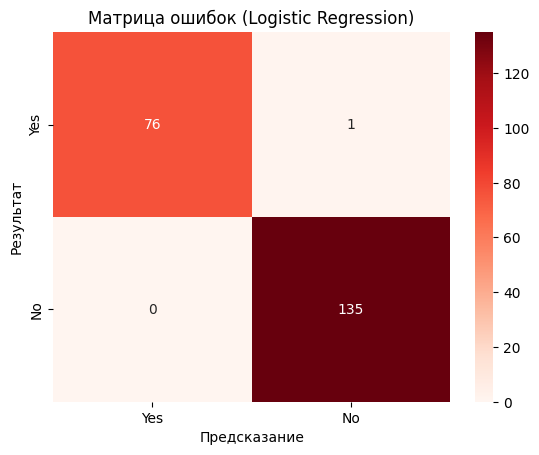

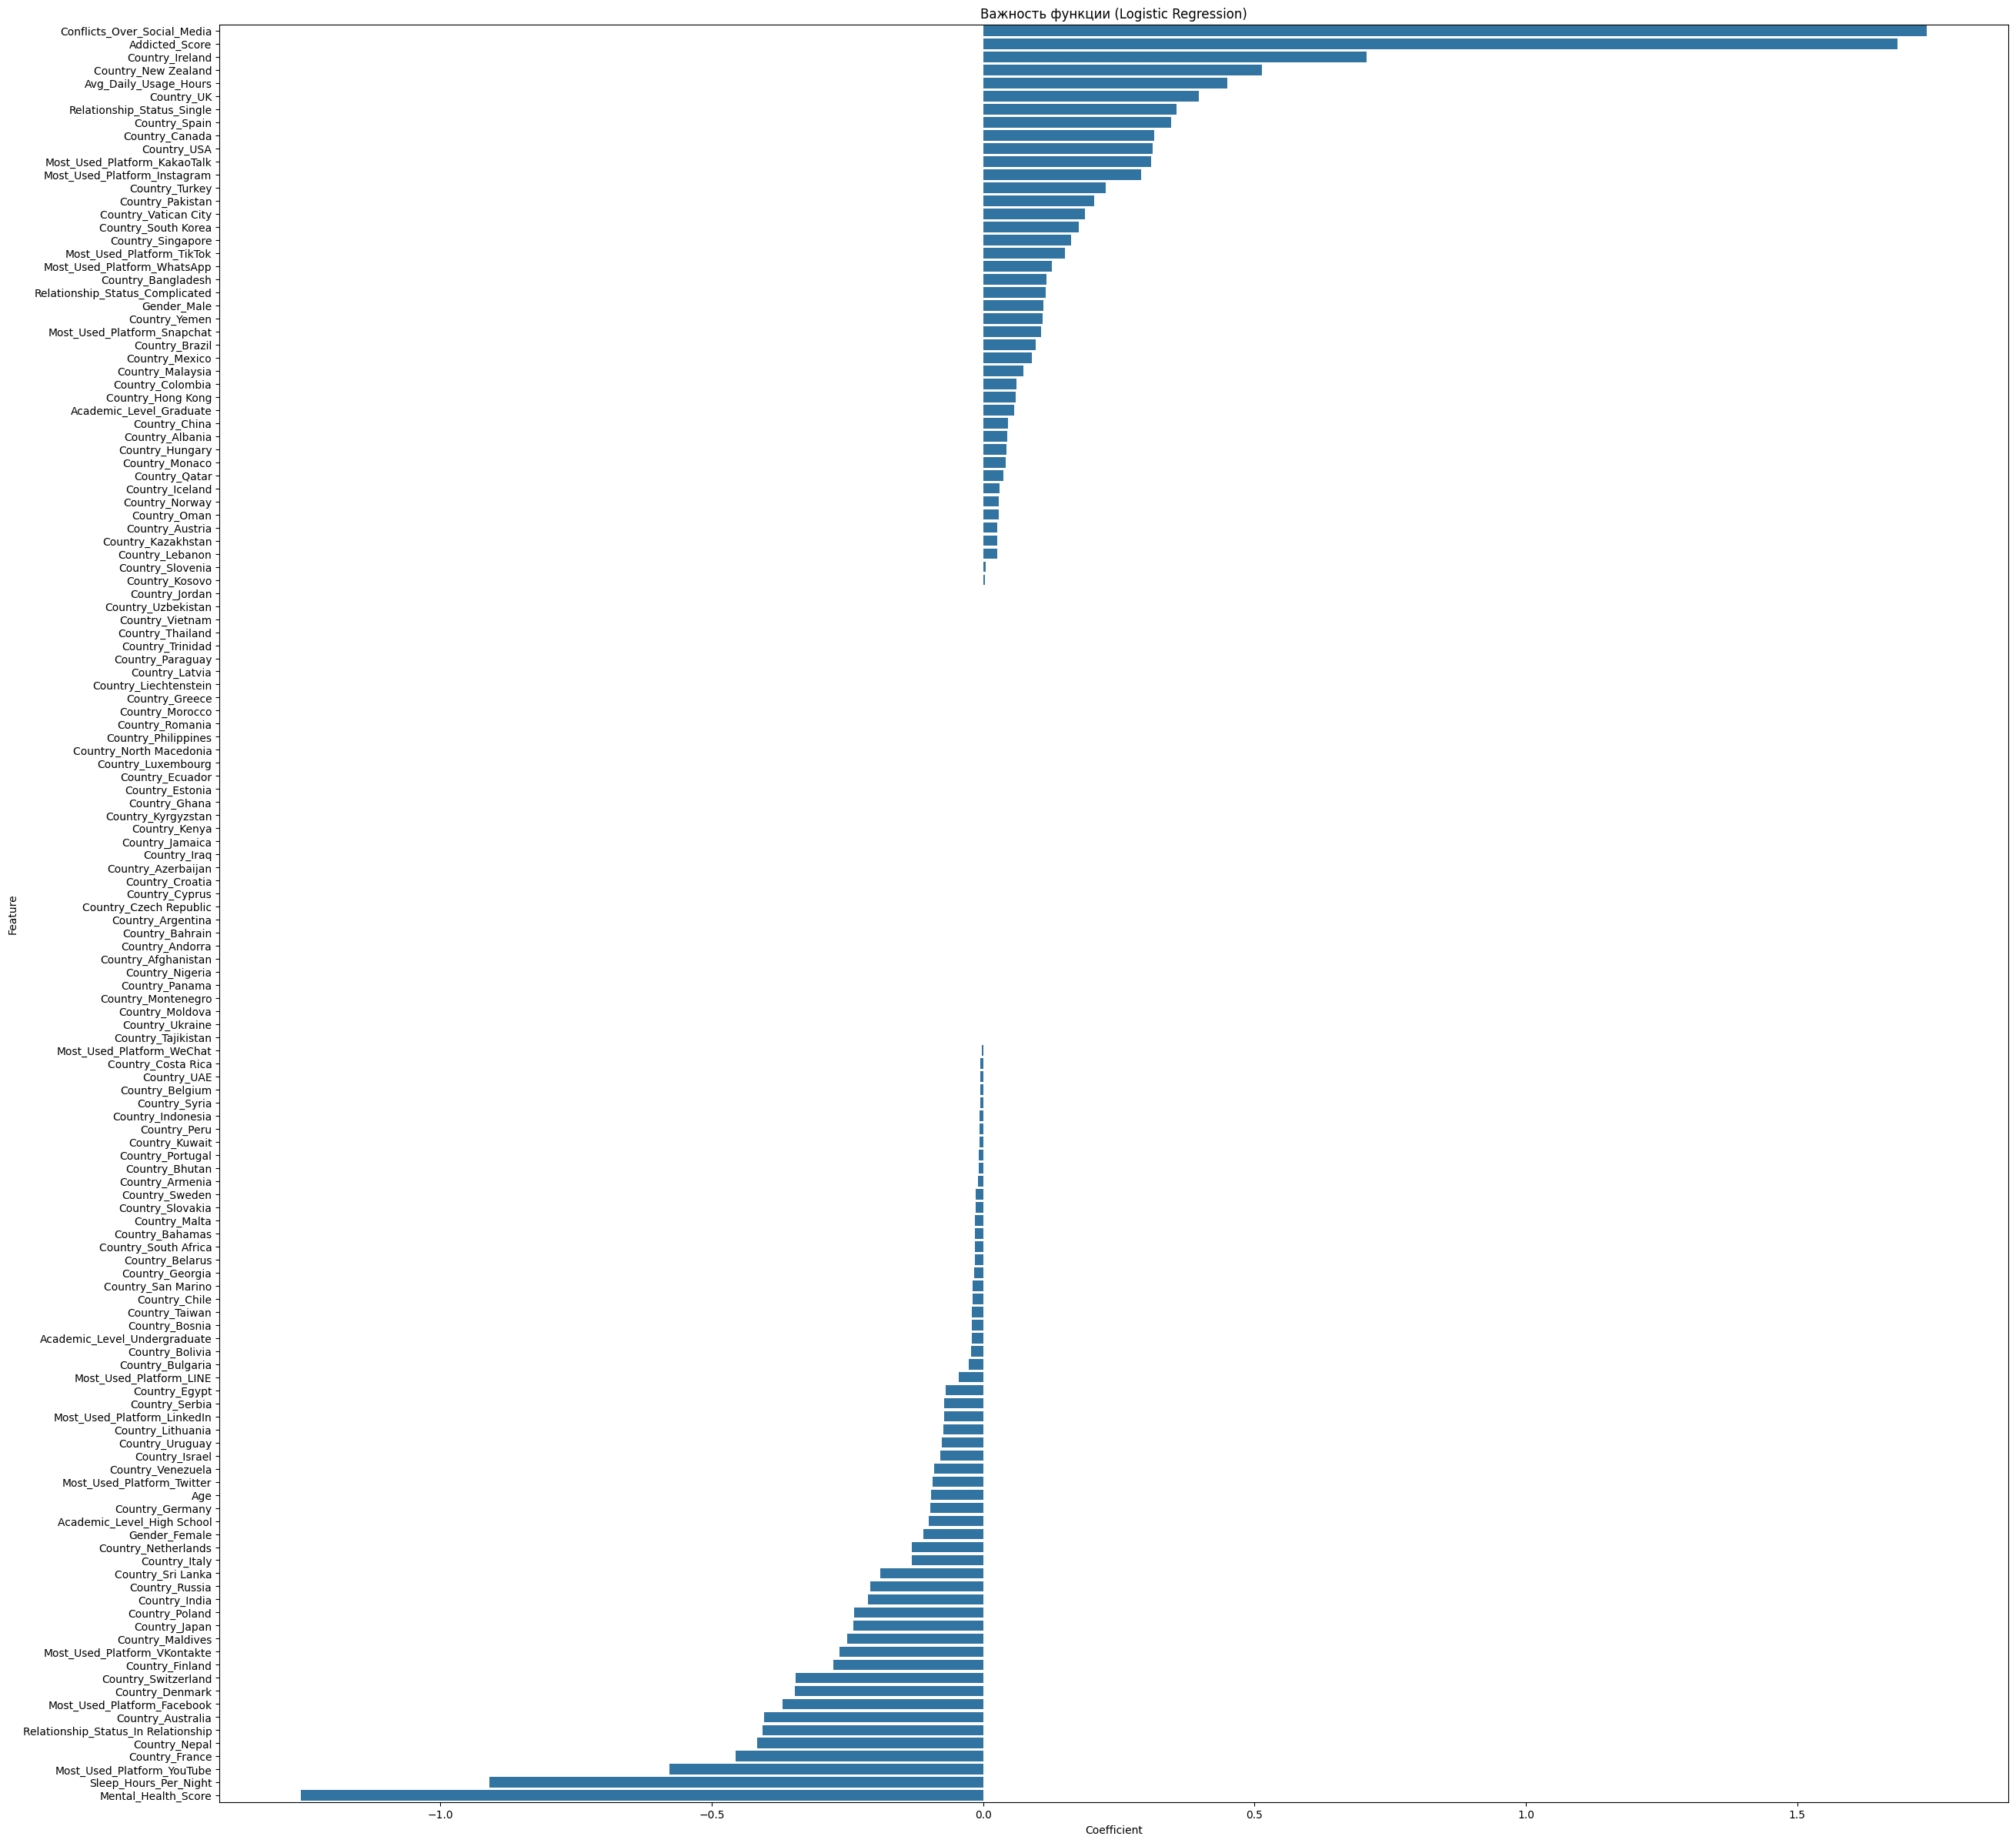

In [ ]:
# Обучение модели Logistic Regression (используем масштабированные данные)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Предсказание и оценка
y_pred = lr_model.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=y.unique(), yticklabels=y.unique())
plt.title("Матрица ошибок (Logistic Regression)")
plt.xlabel("Предсказание")
plt.ylabel("Результат")
plt.show()

# Важность признаков (коэффициенты)
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

plt.figure(figsize=(30, 30))
sns.barplot(x="Coefficient", y="Feature", data=importance)
plt.title("Важность функции (Logistic Regression)")
plt.show()

**Наблюдения:**

Точность этого метода для наших данных больше точности алгоритма k-ближайших сосетей (kNN), но все равно меньше дерева решений (~0,995).

На графике важности признаков мы можем увидеть, какие признаки увеличивали вероятность целевого класса (1) (признаки с коэффициентами > 0), а какие наоборот уменьшали (признаки с коэффициентами < 0). Остальные не сильно влияли на результат.

# **Общий вывод:**

На основе проведенного анализа данных о влиянии социальных сетей на успеваемость студентов можно сделать следующие выводы:

*   Высокая точность моделей: все три модели (Decision Tree, KNN, Logistic Regression) показали отличные результаты, с точностью (accuracy) выше 95%. Это говорит о том, что выбранные признаки хорошо описывают зависимость между использованием соцсетей и успеваемостью.
*   Decision Tree (Дерево решений) показало 100% точность, что может указывать на переобучение или идеальную разделимость данных по выбранным признакам.

Дерево решений оказалось наиболее эффективным по следующим причинам:


1.   Устойчивость к нелинейным зависимостям: в данных могут быть сложные нелинейные взаимосвязи, которые деревья хорошо улавливают.
2.   Автоматический выбор значимых признаков: дерево решений само отбирает наиболее информативные признаки, игнорируя слабые.
3.   Работа с категориальными и числовыми данными: дерево не требует масштабирования данных и корректно обрабатывает как числовые, так и категориальные признаки